In [1]:
from model_driver import driver
from iotools import read_results
import pandas as pd
from dotenv import load_dotenv
import os
from pathlib import Path
load_dotenv()

project_folder = Path(os.getenv('PROJECT_FOLDER'))
input_folder = os.path.join(project_folder, 'SpaFHy-PEAT', 'model_inputs')

In [2]:
# runs model
outputfile = driver(create_ncf=True, folder=input_folder, param_module="parameters_ad")

# reads results from .nc-file
results = read_results(outputfile)

2.4699999999999998 2.47 2.5 -0.03
2.4400000000000004 2.44 2.5 -0.06
2.4299999999999997 2.43 2.5 -0.07
2.4000000000000004 2.4 2.5 -0.1
2.3899999999999997 2.39 2.5 -0.11
2.3600000000000003 2.36 2.5 -0.14
2.3499999999999996 2.35 2.5 -0.15
2.3200000000000003 2.32 2.5 -0.18
2.2800000000000002 2.28 2.5 -0.22
2.1799999999999997 2.18 2.5 -0.32
2.0700000000000003 2.07 2.5 -0.43
2.0300000000000002 2.03 2.5 -0.47000000000000003
2.4699999999999998 2.47 2.5 -0.03
2.4400000000000004 2.44 2.5 -0.06
2.4299999999999997 2.43 2.5 -0.07
2.4000000000000004 2.4 2.5 -0.1
2.3899999999999997 2.39 2.5 -0.11
2.3600000000000003 2.36 2.5 -0.14
2.3499999999999996 2.35 2.5 -0.15
2.3200000000000003 2.32 2.5 -0.18
2.2800000000000002 2.28 2.5 -0.22
2.1799999999999997 2.18 2.5 -0.32
2.0700000000000003 2.07 2.5 -0.43
2.0300000000000002 2.03 2.5 -0.47000000000000003
*** Running model ***
*** Writing results to netCDF4-file, subset 1/30 ***
*** Writing results to netCDF4-file, subset 2/30 ***
*** Writing results to netCDF4

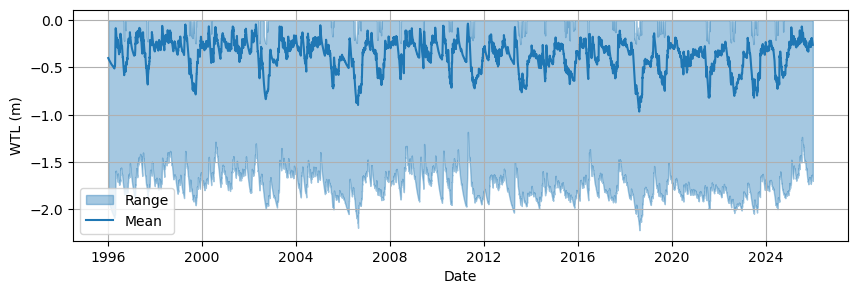

In [3]:
import matplotlib.pyplot as plt

da_min = results['soil_ground_water_level'].min(dim='j')[:,0]
da_max = results['soil_ground_water_level'].max(dim='j')[:,0]

# Extract the time coordinate (replace 'date' with your actual time dim name if different)
time = results['date'].values

# Plot
plt.figure(figsize=(10, 3))
plt.fill_between(time, da_min, da_max, color='tab:blue', alpha=0.4, label='Range')
plt.plot(time, results['soil_ground_water_level'].mean(dim='j'), color='tab:blue', label='Mean')
plt.xlabel("Date")
plt.ylabel("WTL (m)")
plt.legend()
plt.grid(True)

In [4]:
# Select only
summer = results['soil_ground_water_level'].sel(
    date=results['soil_ground_water_level'].date.dt.month.isin([5, 6, 7, 8])
)

# Then take the mean over the summer dates
mean_gw = summer.mean(dim='date')[0, :]
min_gw = summer.min(dim='date')[0, :]
max_gw = summer.max(dim='date')[0, :]

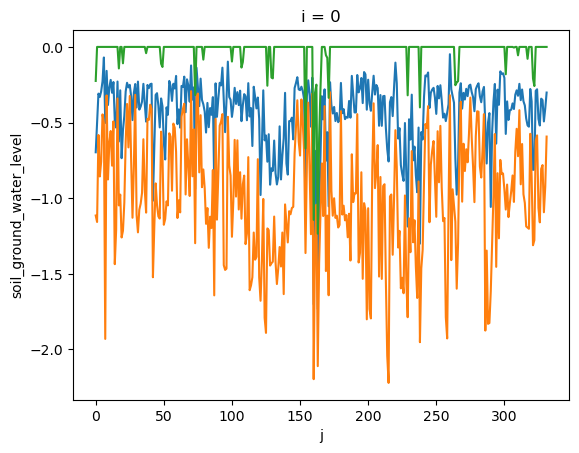

In [5]:
mean_gw.plot()
min_gw.plot()
max_gw.plot()